<a href="https://colab.research.google.com/github/divinagraciabelgica-wq/Belgica_Elec2/blob/main/Lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandasql

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=4b8e9f2c5086c951b1f46a77bef3b5003d8cbfde3bc228b4527d1efe46c350ec
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


In [31]:
import os

filenames = ["departuredelays.csv", "housing.csv", "sf-airbnb.csv", "owid-covid-data.csv"]

for fname in filenames:
    for root, dirs, files in os.walk("/content"):
        if fname in files:
            print(f"✅ Found: {os.path.join(root, fname)}")

✅ Found: /content/departuredelays.csv
✅ Found: /content/sample_data/departuredelays.csv
✅ Found: /content/housing.csv
✅ Found: /content/sample_data/housing.csv
✅ Found: /content/sf-airbnb.csv
✅ Found: /content/sample_data/sf-airbnb.csv
✅ Found: /content/owid-covid-data.csv
✅ Found: /content/sample_data/owid-covid-data.csv


In [33]:
# ============================================================
# Lab Activity 3
# ============================================================

import pandas as pd
import pandasql as ps
import json
import os

print("=" * 60)
print("SECTION 1: Loading Datasets")
print("=" * 60)

df_delays  = pd.read_csv("/content/sample_data/departuredelays.csv")
df_housing = pd.read_csv("/content/housing.csv")
df_airbnb  = pd.read_csv("/content/sample_data/sf-airbnb.csv")
df_covid   = pd.read_csv("/content/sample_data/owid-covid-data.csv")

print(f"✅ Delays  : {df_delays.shape}")
print(f"✅ Housing : {df_housing.shape}")
print(f"✅ Airbnb  : {df_airbnb.shape}")
print(f"✅ Covid   : {df_covid.shape}")


# ============================================================
# SECTION 2: DATA PREPROCESSING
# ============================================================

print("\n" + "=" * 60)
print("SECTION 2: Data Preprocessing")
print("=" * 60)

# ---------- 2A. Check Missing Values ----------
print("\n[Delays] Missing values:")
print(df_delays.isnull().sum())

print("\n[Housing] Missing values:")
print(df_housing.isnull().sum())

print("\n[Airbnb] Missing values (selected columns):")
airbnb_cols = ['property_type', 'room_type', 'neighbourhood_cleansed',
               'price', 'bedrooms', 'bathrooms', 'review_scores_rating']
print(df_airbnb[airbnb_cols].isnull().sum())

print("\n[Covid] Missing values (selected columns):")
covid_cols = ['continent', 'location', 'date', 'total_cases',
              'new_cases', 'total_deaths', 'people_vaccinated']
print(df_covid[covid_cols].isnull().sum())

# ---------- 2B. Drop Missing Values ----------
df_delays_clean  = df_delays.dropna()
df_housing_clean = df_housing.dropna()
df_airbnb_clean  = df_airbnb[airbnb_cols].dropna()
df_covid_clean   = df_covid[covid_cols].dropna()

print(f"\n[Delays]  Before: {len(df_delays):,}  | After: {len(df_delays_clean):,}")
print(f"[Housing] Before: {len(df_housing):,} | After: {len(df_housing_clean):,}")
print(f"[Airbnb]  Before: {len(df_airbnb):,}  | After: {len(df_airbnb_clean):,}")
print(f"[Covid]   Before: {len(df_covid):,} | After: {len(df_covid_clean):,}")

# ---------- 2C. Select Columns ----------
print("\n[Delays] Selected columns:")
df_delays_sel = df_delays_clean[['date', 'delay', 'distance', 'origin', 'destination']]
print(df_delays_sel.head(3))

print("\n[Housing] Selected columns:")
df_housing_sel = df_housing_clean[['housing_median_age', 'median_income',
                                    'median_house_value', 'ocean_proximity']]
print(df_housing_sel.head(3))

print("\n[Airbnb] Selected columns:")
print(df_airbnb_clean.head(3))

print("\n[Covid] Selected columns:")
print(df_covid_clean.head(3))

# ---------- 2D. Filtering ----------
# Flights with actual delays (> 0 minutes)
df_delayed = df_delays_clean[df_delays_clean['delay'] > 0]
print(f"\n[Delays] Flights with delay > 0: {len(df_delayed):,}")

# Houses valued above $200,000
df_expensive = df_housing_clean[df_housing_clean['median_house_value'] > 200000]
print(f"[Housing] Houses above $200,000: {len(df_expensive):,}")

# Airbnb listings with rating >= 90
df_top_airbnb = df_airbnb_clean[df_airbnb_clean['review_scores_rating'] >= 90]
print(f"[Airbnb] Listings rated >= 90: {len(df_top_airbnb):,}")

# Covid records with new_cases > 0
df_active_covid = df_covid_clean[df_covid_clean['new_cases'] > 0]
print(f"[Covid] Records with new_cases > 0: {len(df_active_covid):,}")

# ---------- 2E. Basic Statistics ----------
print("\n[Delays] Delay stats:")
print(df_delays_clean['delay'].describe())

print("\n[Housing] House value stats:")
print(df_housing_clean['median_house_value'].describe())

print("\n[Airbnb] Review score stats:")
print(df_airbnb_clean['review_scores_rating'].describe())

print("\n[Covid] Total cases stats:")
print(df_covid_clean['total_cases'].describe())


# ============================================================
# SECTION 3: ADVANCED SQL QUERIES (pandasql)
# ============================================================

print("\n" + "=" * 60)
print("SECTION 3: Advanced SQL Queries")
print("=" * 60)

# Rename for SQL use
df_delays_sql  = df_delays_clean
df_housing_sql = df_housing_clean
df_airbnb_sql  = df_airbnb_clean
df_covid_sql   = df_covid_clean

# ---- Query 1: Top 5 most frequent Origin Airports ----
q1 = """
    SELECT origin, COUNT(*) AS flight_count
    FROM df_delays_sql
    GROUP BY origin
    ORDER BY flight_count DESC
    LIMIT 5
"""
top5_origins = ps.sqldf(q1, locals())
print("\n[Query 1] Top 5 Most Frequent Origin Airports:")
print(top5_origins.to_string(index=False))

# ---- Query 2: Top 5 Ocean Proximity Categories ----
q2 = """
    SELECT ocean_proximity, COUNT(*) AS count
    FROM df_housing_sql
    GROUP BY ocean_proximity
    ORDER BY count DESC
    LIMIT 5
"""
top5_proximity = ps.sqldf(q2, locals())
print("\n[Query 2] Top 5 Ocean Proximity Categories (Housing):")
print(top5_proximity.to_string(index=False))

# ---- Query 3: Top 5 most frequent Airbnb Property Types ----
q3 = """
    SELECT property_type, COUNT(*) AS count
    FROM df_airbnb_sql
    GROUP BY property_type
    ORDER BY count DESC
    LIMIT 5
"""
top5_property = ps.sqldf(q3, locals())
print("\n[Query 3] Top 5 Most Frequent Airbnb Property Types:")
print(top5_property.to_string(index=False))

# ---- Query 4: Top 5 most frequent Airbnb Room Types ----
q4 = """
    SELECT room_type, COUNT(*) AS count
    FROM df_airbnb_sql
    GROUP BY room_type
    ORDER BY count DESC
    LIMIT 5
"""
top5_rooms = ps.sqldf(q4, locals())
print("\n[Query 4] Top 5 Most Frequent Airbnb Room Types:")
print(top5_rooms.to_string(index=False))

# ---- Query 5: Top 5 Locations by Total COVID Cases ----
q5 = """
    SELECT location, MAX(total_cases) AS max_total_cases
    FROM df_covid_sql
    GROUP BY location
    ORDER BY max_total_cases DESC
    LIMIT 5
"""
top5_covid = ps.sqldf(q5, locals())
print("\n[Query 5] Top 5 Locations by Total COVID Cases:")
print(top5_covid.to_string(index=False))

#---- Query 6: Top 5 Origins with Highest Average Delay ----
q6 = """
    SELECT origin, ROUND(AVG(delay), 2) AS avg_delay
    FROM df_delays_sql
    WHERE delay > 0
    GROUP BY origin
    ORDER BY avg_delay DESC
    LIMIT 5
"""
top5_avg_delay = ps.sqldf(q6, locals())
print("\n[Query 6] Top 5 Origins with Highest Average Delay (min):")
print(top5_avg_delay.to_string(index=False))


print("\n" + "=" * 60)
print("SECTION 4: Writing Results to External Storage")
print("=" * 60)

os.makedirs("/content/output", exist_ok=True)

top5_origins.to_csv("/content/output/top5_origins.csv", index=False)
top5_proximity.to_csv("/content/output/top5_ocean_proximity.csv", index=False)
top5_property.to_csv("/content/output/top5_airbnb_property.csv", index=False)
top5_covid.to_csv("/content/output/top5_covid_locations.csv", index=False)
print("✅ CSV files saved to /content/output/")

top5_origins.to_json("/content/output/top5_origins.json", orient="records", indent=2)
top5_proximity.to_json("/content/output/top5_ocean_proximity.json", orient="records", indent=2)
top5_property.to_json("/content/output/top5_airbnb_property.json", orient="records", indent=2)
top5_covid.to_json("/content/output/top5_covid_locations.json", orient="records", indent=2)
print("✅ JSON files saved to /content/output/")

with open("/content/output/summary_report.txt", "w") as f:
    f.write("=" * 60 + "\n")
    f.write("LAB ACTIVITY 1 - SUMMARY REPORT\n")
    f.write("=" * 60 + "\n\n")

    f.write("DATASET 1: Departure Delays\n")
    f.write(f"  Total records  : {len(df_delays_clean):,}\n")
    f.write(f"  Delayed flights: {len(df_delayed):,}\n")
    f.write(f"  Avg delay (delayed only): {df_delayed['delay'].mean():.2f} min\n\n")
    f.write("Top 5 Most Frequent Origin Airports:\n")
    f.write(top5_origins.to_string(index=False) + "\n\n")
    f.write("Top 5 Origins - Highest Avg Delay:\n")
    f.write(top5_avg_delay.to_string(index=False) + "\n\n")

    f.write("DATASET 2: California Housing\n")
    f.write(f"  Total records: {len(df_housing_clean):,}\n\n")
    f.write("Top 5 Ocean Proximity Categories:\n")
    f.write(top5_proximity.to_string(index=False) + "\n\n")

    f.write("DATASET 3: SF Airbnb\n")
    f.write(f"  Total records: {len(df_airbnb_clean):,}\n\n")
    f.write("Top 5 Property Types:\n")
    f.write(top5_property.to_string(index=False) + "\n\n")
    f.write("Top 5 Room Types:\n")
    f.write(top5_rooms.to_string(index=False) + "\n\n")

    f.write("DATASET 4: COVID-19 Data\n")
    f.write(f"  Total records: {len(df_covid_clean):,}\n\n")
    f.write("Top 5 Locations by Total Cases:\n")
    f.write(top5_covid.to_string(index=False) + "\n")

print("✅ TXT report saved to /content/output/summary_report.txt")

print("\n" + "=" * 60)
print("✅ Lab Activity Complete! Check /content/output/ folder.")
print("=" * 60)

SECTION 1: Loading Datasets
✅ Delays  : (1391578, 5)
✅ Housing : (20640, 10)
✅ Airbnb  : (7151, 106)
✅ Covid   : (429435, 67)

SECTION 2: Data Preprocessing

[Delays] Missing values:
date           0
delay          0
distance       0
origin         0
destination    0
dtype: int64

[Housing] Missing values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

[Airbnb] Missing values (selected columns):
property_type                0
room_type                    0
neighbourhood_cleansed       0
price                        0
bedrooms                     2
bathrooms                   21
review_scores_rating      1421
dtype: int64

[Covid] Missing values (selected columns):
continent             26525
location                  0
date                      0
total_cases     

In [34]:
from google.colab import files

files.download("/content/output/summary_report.txt")
files.download("/content/output/top5_origins.csv")
files.download("/content/output/top5_ocean_proximity.csv")
files.download("/content/output/top5_airbnb_property.csv")
files.download("/content/output/top5_covid_locations.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
import os
filenames = ["departuredelays.csv", "housing.csv", "sf-airbnb.csv", "owid-covid-data.csv"]
for fname in filenames:
    for root, dirs, files in os.walk("/content"):
        if fname in files:
            print(f"✅ Found: {os.path.join(root, fname)}")

✅ Found: /content/departuredelays.csv
✅ Found: /content/sample_data/departuredelays.csv
✅ Found: /content/housing.csv
✅ Found: /content/sample_data/housing.csv
✅ Found: /content/sf-airbnb.csv
✅ Found: /content/sample_data/sf-airbnb.csv
✅ Found: /content/owid-covid-data.csv
✅ Found: /content/sample_data/owid-covid-data.csv


In [36]:
import shutil
import os

# Copy all datasets to /content/ so both Lab 1 and Lab 2 work
files_to_copy = [
    "/content/sample_data/departuredelays.csv",
    "/content/sample_data/sf-airbnb.csv",
    "/content/sample_data/owid-covid-data.csv"
]

for f in files_to_copy:
    filename = os.path.basename(f)
    dest = f"/content/{filename}"
    if not os.path.exists(dest):
        shutil.copy(f, dest)
        print(f"✅ Copied: {filename}")
    else:
        print(f"✅ Already exists: {filename}")

# housing.csv should already be in /content/
if os.path.exists("/content/housing.csv"):
    print("✅ housing.csv already in /content/")
else:
    shutil.copy("/content/sample_data/housing.csv", "/content/housing.csv")
    print("✅ Copied: housing.csv")

✅ Already exists: departuredelays.csv
✅ Already exists: sf-airbnb.csv
✅ Already exists: owid-covid-data.csv
✅ housing.csv already in /content/


In [25]:
import shutil
from google.colab import files

shutil.make_archive("/content/plots", "zip", "/content/output/plots")
files.download("/content/plots.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
import os
files = ["departuredelays.csv", "housing.csv", "sf-airbnb.csv", "owid-covid-data.csv"]
for f in files:
    print("✅" if os.path.exists(f"/content/{f}") else "❌", f)

✅ departuredelays.csv
✅ housing.csv
✅ sf-airbnb.csv
✅ owid-covid-data.csv


In [20]:
import shutil
from google.colab import files
shutil.make_archive("/content/plots", "zip", "/content/output/plots")
files.download("/content/plots.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
import os

os.makedirs("/content/output/plots", exist_ok=True)
print("✅ Output folder ready!")

# Check datasets
files = ["departuredelays.csv", "housing.csv", "sf-airbnb.csv", "owid-covid-data.csv"]
for f in files:
    print("✅" if os.path.exists(f"/content/{f}") else "❌ MISSING:", f)

✅ Output folder ready!
✅ departuredelays.csv
✅ housing.csv
✅ sf-airbnb.csv
✅ owid-covid-data.csv


Datasets loaded and cleaned successfully!
Delays: (1391578, 5) | Housing: (20433, 10)
Airbnb: (5708, 7) | Covid: (60745, 7)

--- Generating Matplotlib Visualizations ---


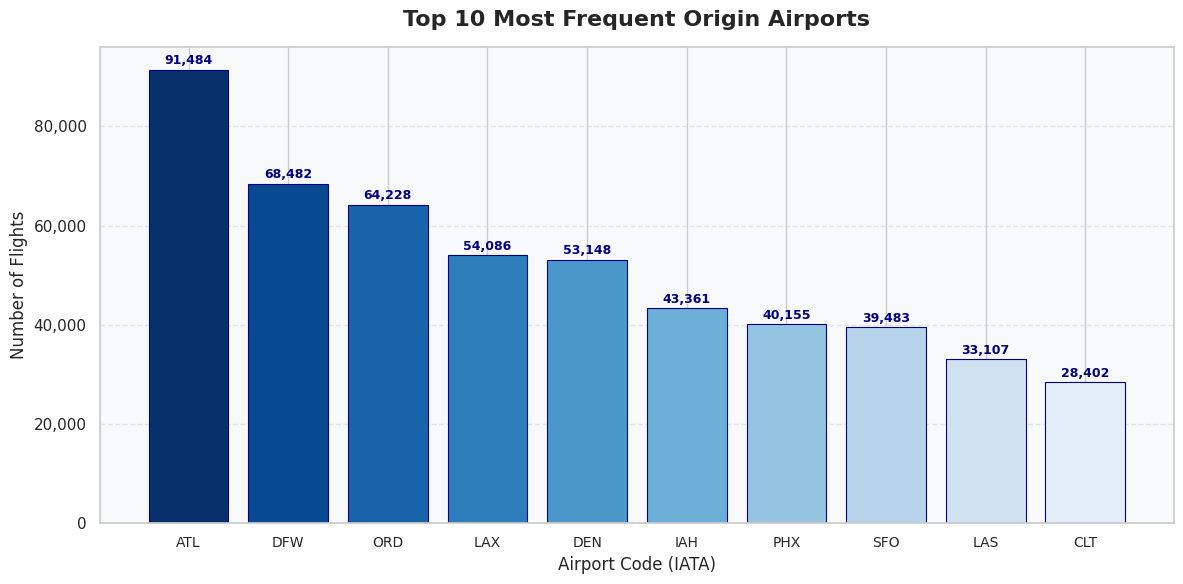

Saved: matplotlib_1_top10_origins.png


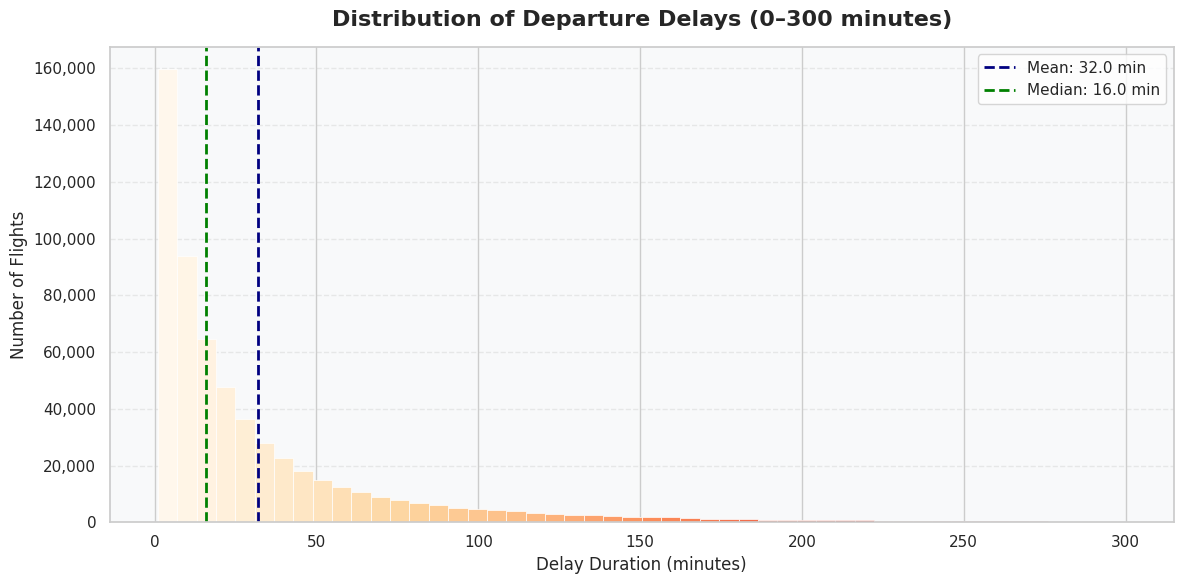

Saved: matplotlib_2_delay_distribution.png


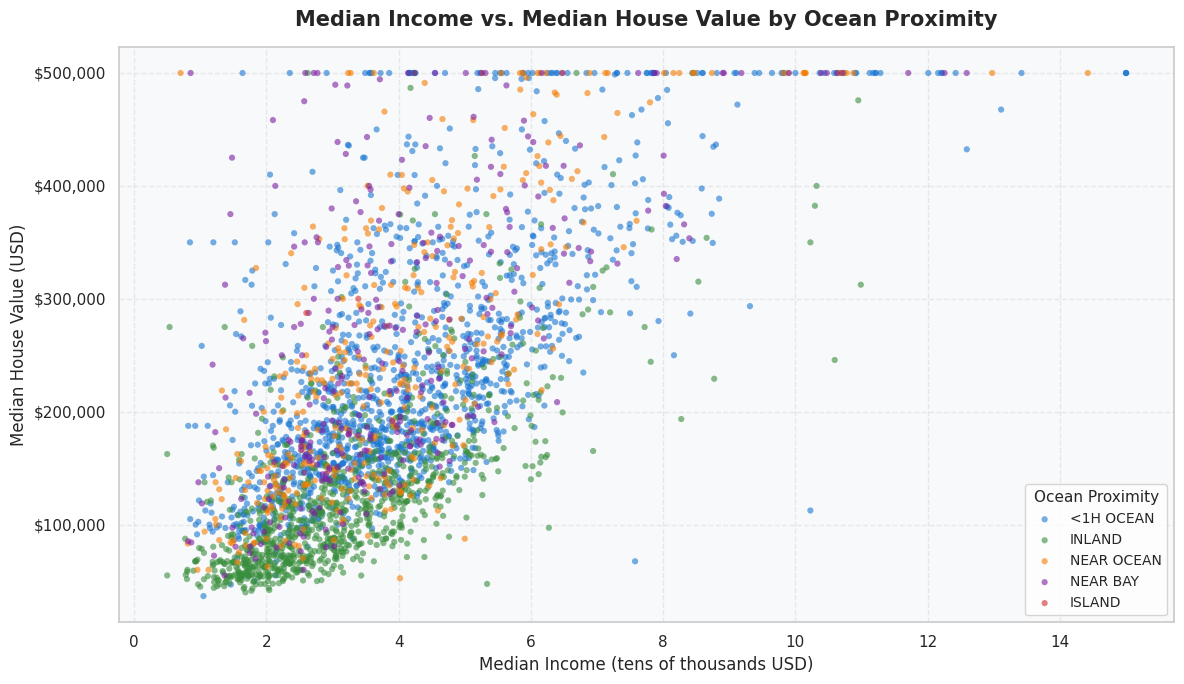

Saved: matplotlib_3_income_vs_value.png


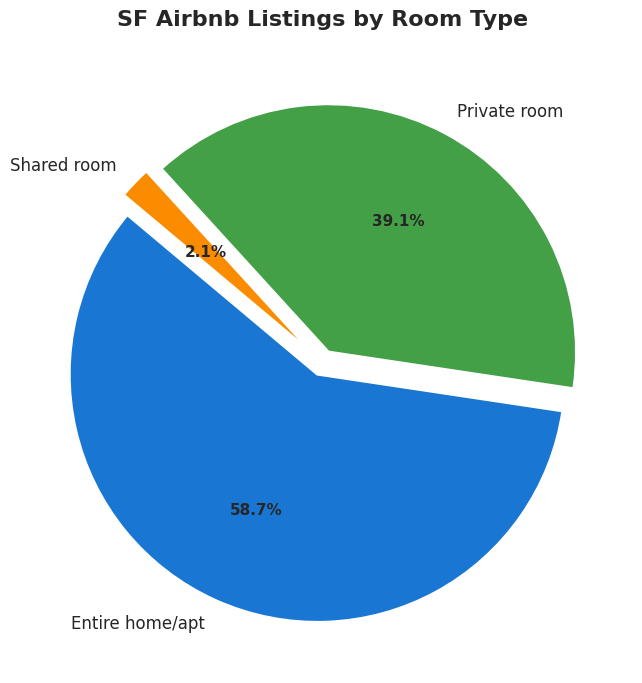

Saved: matplotlib_4_room_type_pie.png


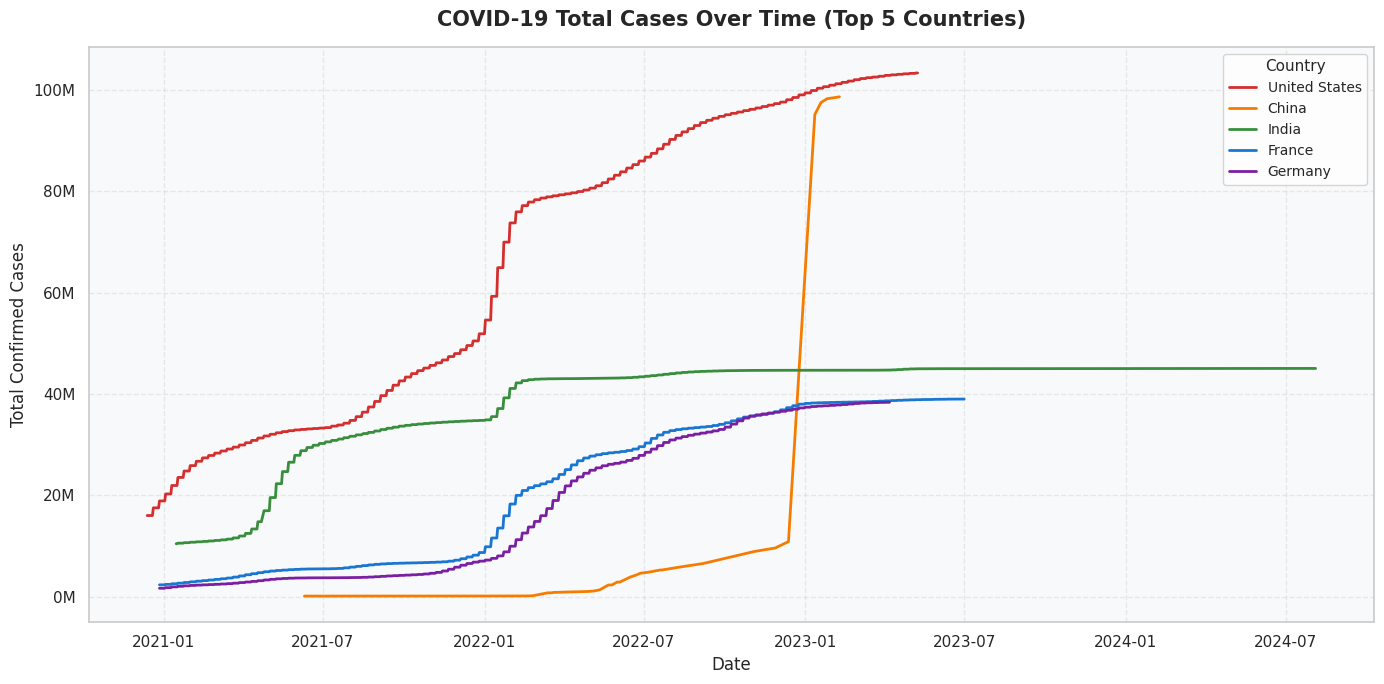

Saved: matplotlib_5_covid_timeline.png

--- Generating Seaborn Visualizations ---


/tmp/ipykernel_27890/1267715703.py:196: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_top10_props,


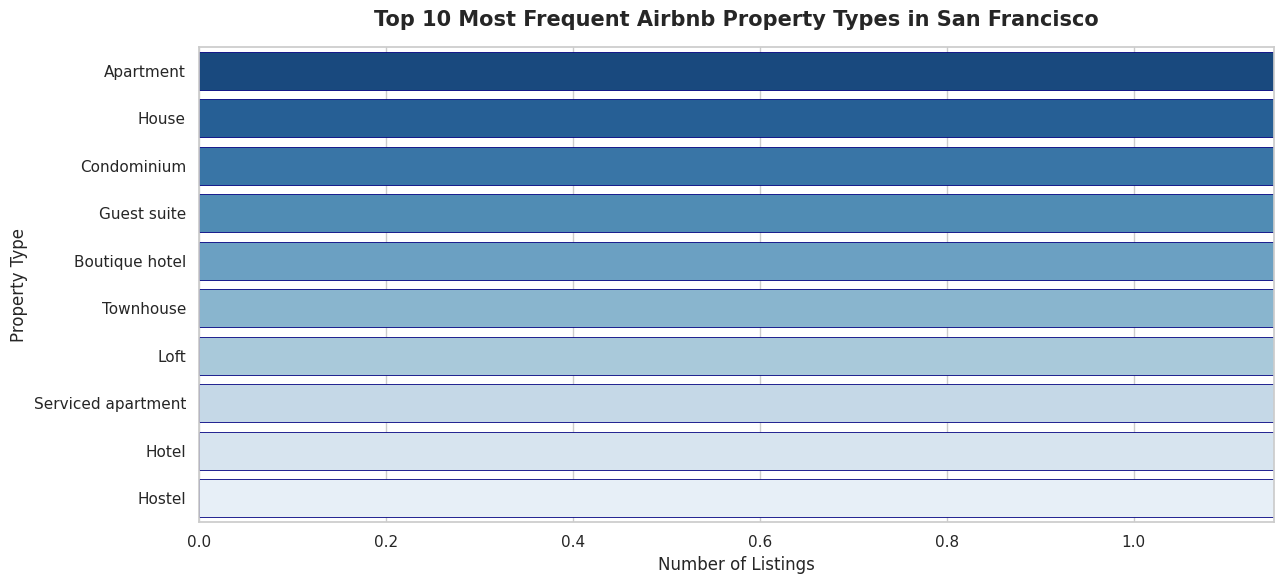

Saved: seaborn_1_property_types.png


/tmp/ipykernel_27890/1267715703.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_housing_clean,


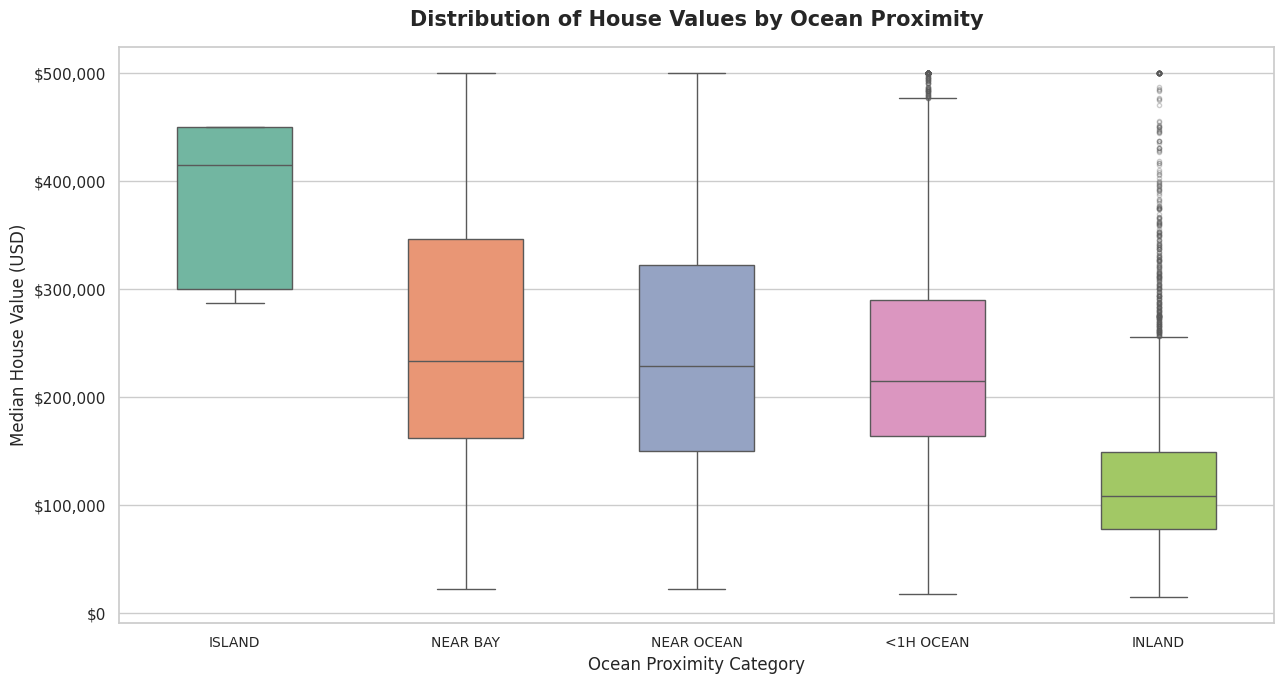

Saved: seaborn_2_house_value_boxplot.png


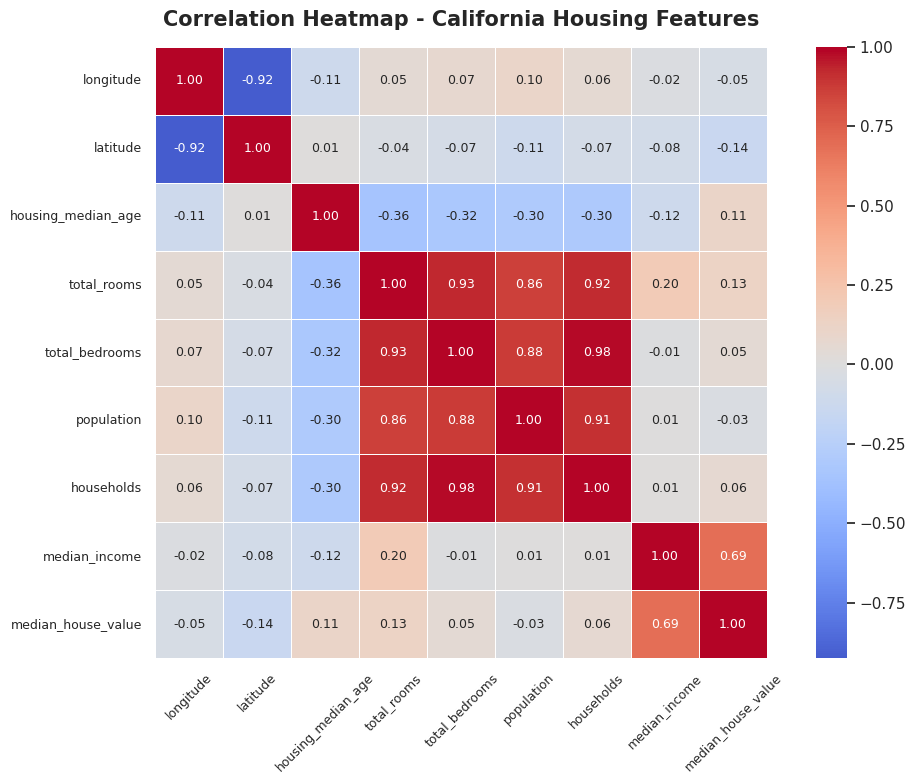

Saved: seaborn_3_housing_heatmap.png


/tmp/ipykernel_27890/1267715703.py:268: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_airbnb_clean,


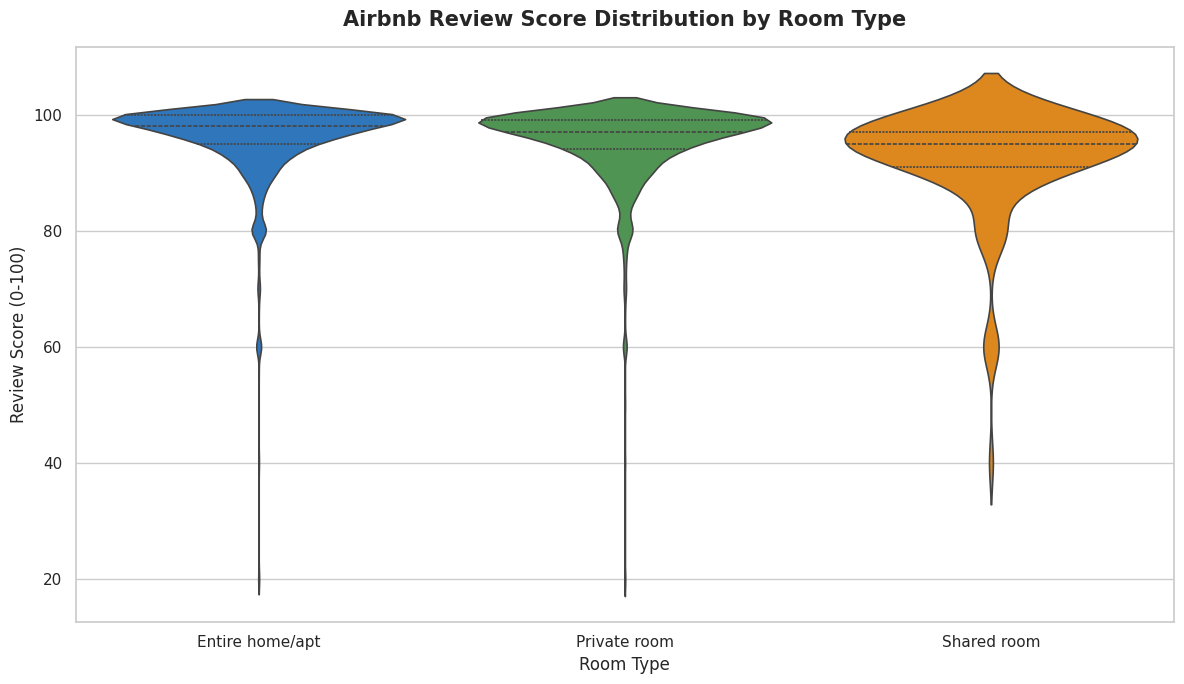

Saved: seaborn_4_review_violin.png


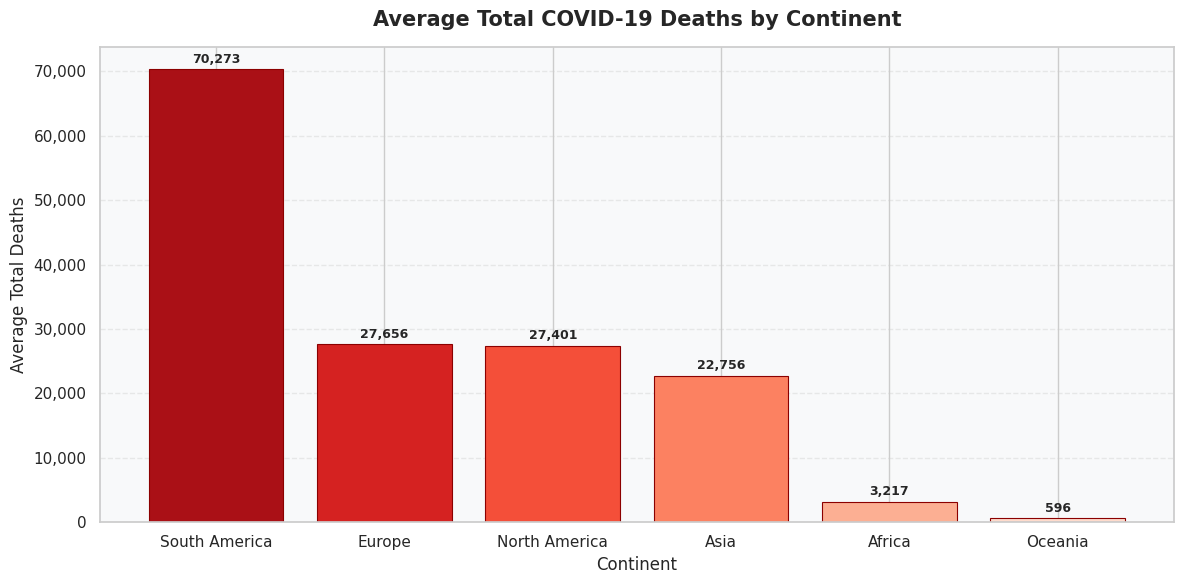

Saved: seaborn_5_covid_deaths_continent.png

Lab 4 Complete! All 10 visualizations saved to:
/content/output/plots/


In [37]:
# ============================================================
# ELEC2 - Lab Activity 4
# Data Visualization using Matplotlib and Seaborn
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# ============================================================
# SETUP - Load Datasets (reusing from Lab 1)
# ============================================================

df_delays  = pd.read_csv("/content/sample_data/departuredelays.csv")
df_housing = pd.read_csv("/content/housing.csv")
df_airbnb  = pd.read_csv("/content/sample_data/sf-airbnb.csv")
df_covid   = pd.read_csv("/content/sample_data/owid-covid-data.csv")

# --- Clean data (same as Lab 1) ---
df_delays_clean  = df_delays.dropna()
df_housing_clean = df_housing.dropna()

airbnb_cols = ['property_type', 'room_type', 'neighbourhood_cleansed',
               'price', 'bedrooms', 'bathrooms', 'review_scores_rating']
df_airbnb_clean = df_airbnb[airbnb_cols].dropna()

covid_cols = ['continent', 'location', 'date', 'total_cases',
              'new_cases', 'total_deaths', 'people_vaccinated']
df_covid_clean = df_covid[covid_cols].dropna()

# Output folder
os.makedirs("/content/output/plots", exist_ok=True)

print("Datasets loaded and cleaned successfully!")
print(f"Delays: {df_delays_clean.shape} | Housing: {df_housing_clean.shape}")
print(f"Airbnb: {df_airbnb_clean.shape} | Covid: {df_covid_clean.shape}")


# ============================================================
# MATPLOTLIB VISUALIZATIONS (5 charts)
# ============================================================

print("\n--- Generating Matplotlib Visualizations ---")

# ---- MATPLOTLIB 1: Bar Chart - Top 10 Origin Airports ----
top10_origins = (df_delays_clean.groupby('origin')
                 .size().reset_index(name='flight_count')
                 .sort_values('flight_count', ascending=False).head(10))

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.Blues_r([i / len(top10_origins) for i in range(len(top10_origins))])
bars = ax.bar(top10_origins['origin'], top10_origins['flight_count'], color=colors, edgecolor='navy', linewidth=0.8)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 500,
            f"{int(bar.get_height()):,}",
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='navy')

ax.set_title("Top 10 Most Frequent Origin Airports", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Airport Code (IATA)", fontsize=12)
ax.set_ylabel("Number of Flights", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', labelsize=10)
plt.tight_layout()
plt.savefig("/content/output/plots/matplotlib_1_top10_origins.png", dpi=150)
plt.show()
print("Saved: matplotlib_1_top10_origins.png")


# ---- MATPLOTLIB 2: Histogram - Distribution of Departure Delays ----
delayed_only = df_delays_clean[df_delays_clean['delay'] > 0]['delay']
delayed_only_clipped = delayed_only[delayed_only <= 300]

fig, ax = plt.subplots(figsize=(12, 6))
n, bins, patches = ax.hist(delayed_only_clipped, bins=50, edgecolor='white', linewidth=0.5)

# Color gradient on bars
for i, patch in enumerate(patches):
    patch.set_facecolor(plt.cm.OrRd(i / len(patches)))

ax.set_title("Distribution of Departure Delays (0–300 minutes)", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Delay Duration (minutes)", fontsize=12)
ax.set_ylabel("Number of Flights", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.axvline(delayed_only_clipped.mean(), color='navy', linestyle='--', linewidth=2, label=f"Mean: {delayed_only_clipped.mean():.1f} min")
ax.axvline(delayed_only_clipped.median(), color='green', linestyle='--', linewidth=2, label=f"Median: {delayed_only_clipped.median():.1f} min")
ax.legend(fontsize=11)
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("/content/output/plots/matplotlib_2_delay_distribution.png", dpi=150)
plt.show()
print("Saved: matplotlib_2_delay_distribution.png")


# ---- MATPLOTLIB 3: Scatter Plot - Housing Income vs House Value ----
sample_housing = df_housing_clean.sample(3000, random_state=42)
proximity_colors = {
    '<1H OCEAN': '#1976D2',
    'INLAND':    '#388E3C',
    'NEAR OCEAN':'#F57C00',
    'NEAR BAY':  '#7B1FA2',
    'ISLAND':    '#D32F2F'
}

fig, ax = plt.subplots(figsize=(12, 7))
for prox, color in proximity_colors.items():
    subset = sample_housing[sample_housing['ocean_proximity'] == prox]
    ax.scatter(subset['median_income'], subset['median_house_value'],
               c=color, label=prox, alpha=0.6, s=20, edgecolors='none')

ax.set_title("Median Income vs. Median House Value by Ocean Proximity", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Median Income (tens of thousands USD)", fontsize=12)
ax.set_ylabel("Median House Value (USD)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x):,}"))
ax.legend(title="Ocean Proximity", fontsize=10, title_fontsize=11)
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("/content/output/plots/matplotlib_3_income_vs_value.png", dpi=150)
plt.show()
print("Saved: matplotlib_3_income_vs_value.png")


# ---- MATPLOTLIB 4: Pie Chart - Airbnb Room Types ----
room_counts = df_airbnb_clean['room_type'].value_counts()
pie_colors  = ['#1976D2', '#43A047', '#FB8C00', '#E53935']
explode     = [0.05] * len(room_counts)

fig, ax = plt.subplots(figsize=(9, 7))
wedges, texts, autotexts = ax.pie(
    room_counts, labels=room_counts.index, autopct='%1.1f%%',
    colors=pie_colors[:len(room_counts)], explode=explode,
    startangle=140, textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

ax.set_title("SF Airbnb Listings by Room Type", fontsize=16, fontweight='bold', pad=20)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig("/content/output/plots/matplotlib_4_room_type_pie.png", dpi=150)
plt.show()
print("Saved: matplotlib_4_room_type_pie.png")


# ---- MATPLOTLIB 5: Line Chart - COVID Cases Over Time (Top 5 Countries) ----
top5_countries = ['United States', 'China', 'India', 'France', 'Germany']
line_colors    = ['#D32F2F', '#F57C00', '#388E3C', '#1976D2', '#7B1FA2']

df_covid_clean['date'] = pd.to_datetime(df_covid_clean['date'])
df_top5 = df_covid_clean[df_covid_clean['location'].isin(top5_countries)]

fig, ax = plt.subplots(figsize=(14, 7))
for country, color in zip(top5_countries, line_colors):
    data = df_top5[df_top5['location'] == country].sort_values('date')
    ax.plot(data['date'], data['total_cases'], label=country, color=color, linewidth=2)

ax.set_title("COVID-19 Total Cases Over Time (Top 5 Countries)", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Total Confirmed Cases", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
ax.legend(title="Country", fontsize=10, title_fontsize=11)
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("/content/output/plots/matplotlib_5_covid_timeline.png", dpi=150)
plt.show()
print("Saved: matplotlib_5_covid_timeline.png")


# ============================================================
# SEABORN VISUALIZATIONS (5 charts)
# ============================================================

print("\n--- Generating Seaborn Visualizations ---")
sns.set_theme(style="whitegrid", palette="deep")


# ---- SEABORN 1: Count Plot - Top 10 Airbnb Property Types ----
top10_props = df_airbnb_clean['property_type'].value_counts().head(10).index
df_top10_props = df_airbnb_clean[df_airbnb_clean['property_type'].isin(top10_props)]

fig, ax = plt.subplots(figsize=(13, 6))
sns.countplot(data=df_top10_props,
              y='property_type',
              order=top10_props,
              palette='Blues_r',
              edgecolor='navy',
              linewidth=0.6,
              ax=ax)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=5, fontsize=10, fontweight='bold')

ax.set_title("Top 10 Most Frequent Airbnb Property Types in San Francisco",
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Number of Listings", fontsize=12)
ax.set_ylabel("Property Type", fontsize=12)
ax.set_xlim(0, top10_props.value_counts().max() * 1.15 if hasattr(top10_props, 'value_counts') else 2600)
plt.tight_layout()
plt.savefig("/content/output/plots/seaborn_1_property_types.png", dpi=150)
plt.show()
print("Saved: seaborn_1_property_types.png")


# ---- SEABORN 2: Box Plot - House Value by Ocean Proximity ----
fig, ax = plt.subplots(figsize=(13, 7))
proximity_order = df_housing_clean.groupby('ocean_proximity')['median_house_value'].median().sort_values(ascending=False).index

sns.boxplot(data=df_housing_clean,
            x='ocean_proximity',
            y='median_house_value',
            order=proximity_order,
            palette='Set2',
            width=0.5,
            flierprops=dict(marker='o', markersize=3, alpha=0.3),
            ax=ax)

ax.set_title("Distribution of House Values by Ocean Proximity", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Ocean Proximity Category", fontsize=12)
ax.set_ylabel("Median House Value (USD)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x):,}"))
ax.tick_params(axis='x', labelsize=10)
plt.tight_layout()
plt.savefig("/content/output/plots/seaborn_2_house_value_boxplot.png", dpi=150)
plt.show()
print("Saved: seaborn_2_house_value_boxplot.png")


# ---- SEABORN 3: Heatmap - Correlation Matrix (Housing) ----
housing_numeric = df_housing_clean.select_dtypes(include='number')
corr_matrix = housing_numeric.corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = pd.DataFrame(False, index=corr_matrix.index, columns=corr_matrix.columns)

sns.heatmap(corr_matrix,
            annot=True, fmt=".2f",
            cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='white',
            square=True,
            annot_kws={"size": 9},
            ax=ax)

ax.set_title("Correlation Heatmap - California Housing Features", fontsize=15, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.savefig("/content/output/plots/seaborn_3_housing_heatmap.png", dpi=150)
plt.show()
print("Saved: seaborn_3_housing_heatmap.png")


# ---- SEABORN 4: Violin Plot - Airbnb Review Scores by Room Type ----
fig, ax = plt.subplots(figsize=(12, 7))
sns.violinplot(data=df_airbnb_clean,
               x='room_type',
               y='review_scores_rating',
               palette=['#1976D2', '#43A047', '#FB8C00'],
               inner='quartile',
               linewidth=1.2,
               ax=ax)

ax.set_title("Airbnb Review Score Distribution by Room Type", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Room Type", fontsize=12)
ax.set_ylabel("Review Score (0-100)", fontsize=12)
ax.tick_params(axis='x', labelsize=11)
plt.tight_layout()
plt.savefig("/content/output/plots/seaborn_4_review_violin.png", dpi=150)
plt.show()
print("Saved: seaborn_4_review_violin.png")


# ---- SEABORN 5: Bar Plot - Avg COVID Deaths by Continent ----
df_covid_continent = df_covid[['continent', 'total_deaths']].dropna()
continent_avg = (df_covid_continent.groupby('continent')['total_deaths']
                 .mean().reset_index()
                 .sort_values('total_deaths', ascending=False))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(continent_avg['continent'],
              continent_avg['total_deaths'],
              color=sns.color_palette('Reds_r', len(continent_avg)),
              edgecolor='darkred',
              linewidth=0.8)

for bar, val in zip(bars, continent_avg['total_deaths']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 500,
            f"{val:,.0f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title("Average Total COVID-19 Deaths by Continent", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Continent", fontsize=12)
ax.set_ylabel("Average Total Deaths", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.tick_params(axis='x', labelsize=11)
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("/content/output/plots/seaborn_5_covid_deaths_continent.png", dpi=150)
plt.show()
print("Saved: seaborn_5_covid_deaths_continent.png")


print("\n" + "="*60)
print("Lab 4 Complete! All 10 visualizations saved to:")
print("/content/output/plots/")
print("="*60)

In [30]:
import shutil, os
from google.colab import files

plots = os.listdir("/content/output/plots")
print(f"✅ Found {len(plots)} plots!")
for p in sorted(plots):
    print(f"  - {p}")

shutil.make_archive("/content/plots", "zip", "/content/output/plots")
files.download("/content/plots.zip")

✅ Found 10 plots!
  - matplotlib_1_top10_origins.png
  - matplotlib_2_delay_distribution.png
  - matplotlib_3_income_vs_value.png
  - matplotlib_4_room_type_pie.png
  - matplotlib_5_covid_timeline.png
  - seaborn_1_property_types.png
  - seaborn_2_house_value_boxplot.png
  - seaborn_3_housing_heatmap.png
  - seaborn_4_review_violin.png
  - seaborn_5_covid_deaths_continent.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>